# Retrieving Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as scp
import pandas as pd
import os
from matplotlib import colormaps

# Storing the Paths of my Assignment folder. Due to me working on a Windows Desktop PC at home and on a Linux Laptop in Uni, there are two different storing paths.
# To work easier, i comment the one im currently not using out. 
# IF YOU WANT TO USE THE CODE: chose one, and paste in your directory location.
path = r"C:\Users\Peter\Documents\Uni\Master\CRE 3\CRE3-Assignment-1\2026_Task_data"    # Windows Location
# path = "/home/pit/Uni/Master/CRE3/CRE3-Assignment-1/2026_Task_data"                     # Linux Location

# Creating a ist of all files in the above mentioned directory, which contains the data for the assignment.
exp_data = os.listdir(path)

# Storing the length/count of files in the directory, hence equaling the number of experiments
no_of_files = len(exp_data)

# creating empty lists to later store concentration, time and initials in
exp_conc = []                   # list of concentrations of all 6 species for all 6 Experiments, will be a List of 2D arrays
exp_time = []                   # List of Timestamps, where the concentrations got measured each experiment. Will be a List of 1D arrays
init_c_val = []                 # List of initial conzentrations for alle experiments. Will be a List of 1D arrays
for i in np.arange(0, no_of_files): # this is equal to: "for every whole number from 0 to maximum number of files, iterate the index"

    # iterate over all the csv-files and append them to the above initiated lists
    temp_dataframe = pd.read_csv(path + r'\Exp_res_' + str(i) + r'.csv') # Windows Version
    # temp_dataframe = pd.read_csv(path + r'/Exp_res_' + str(i) + r'.csv') # Linux Version

    exp_time.append(temp_dataframe.values.transpose()[0])       # the time values are all values from the first column, hence the [0]
    exp_conc.append(temp_dataframe.values.transpose()[1:])      # the concentration values are all values from the second column, hence the [1:]
    init_c_val.append(temp_dataframe.values.transpose()[1:, 0]) # the initial concentration value is the first value of the second column, hence the [1][0]

# Storing Lists in arrays for better Data manipulation
no_of_exp = len(init_c_val)
ExperimentalData = np.array([])                                 # Storage Container for the experimental Data in form of an array instead of a List
for i in range(no_of_exp):
    ExperimentalData = np.append(ExperimentalData, exp_conc[i])
    ''' 
    np.append appends the second given data (here: exp_conc[i]) 
    to the array given in the first argument (here: ExperimentalData) 
    and returns the expanded array. 
    To store it, we use ExperimentalData itself. 
    
    This gives an array of 1620 entrys flat as a 1D array. We can seperate them later by knowing, that there were 45 measurements for each experiment, and 6 species per experiment.
    This equals to 45(Measurements) x 6(Species) x 6(Experiments) concentrations, wich are in the following Order: [Exp0,ConcA],[Exp0,ConcB],...,[Exp1,ConcA],[Exp,1,ConcB],...,[Exp5,ConcF] (45 Elements in each Set) 
    '''

# Plotting the Experimental Data raw

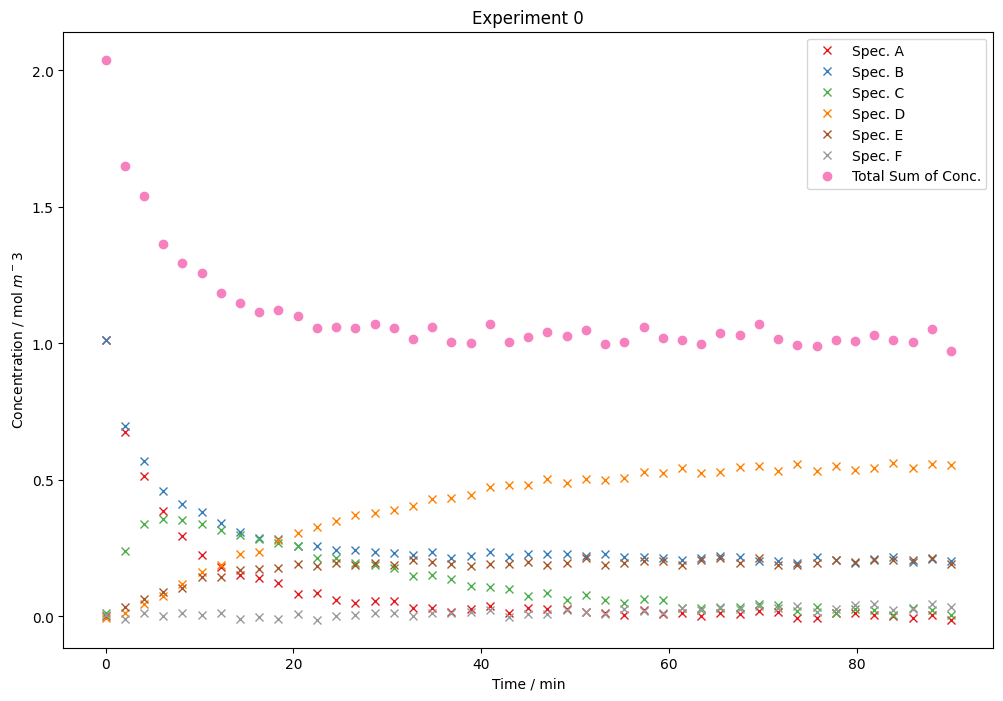

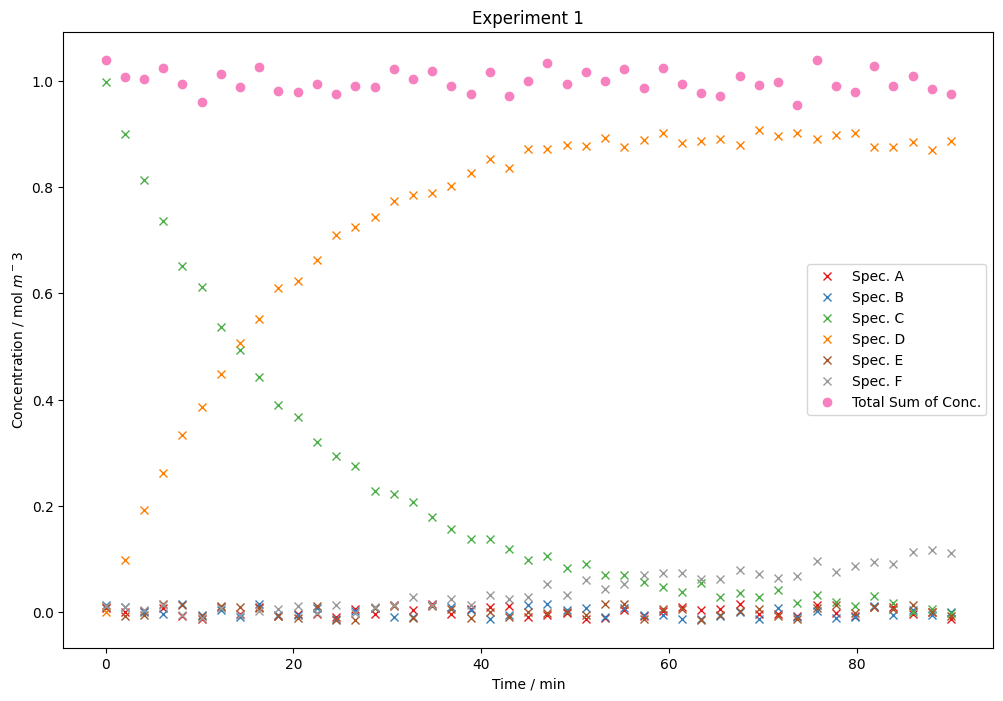

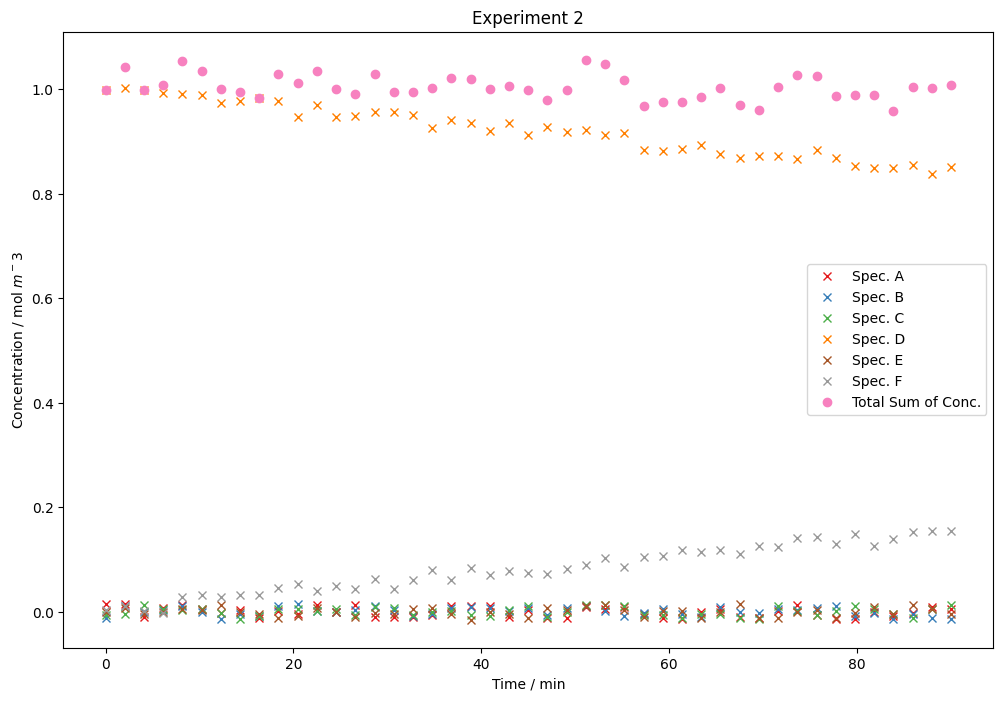

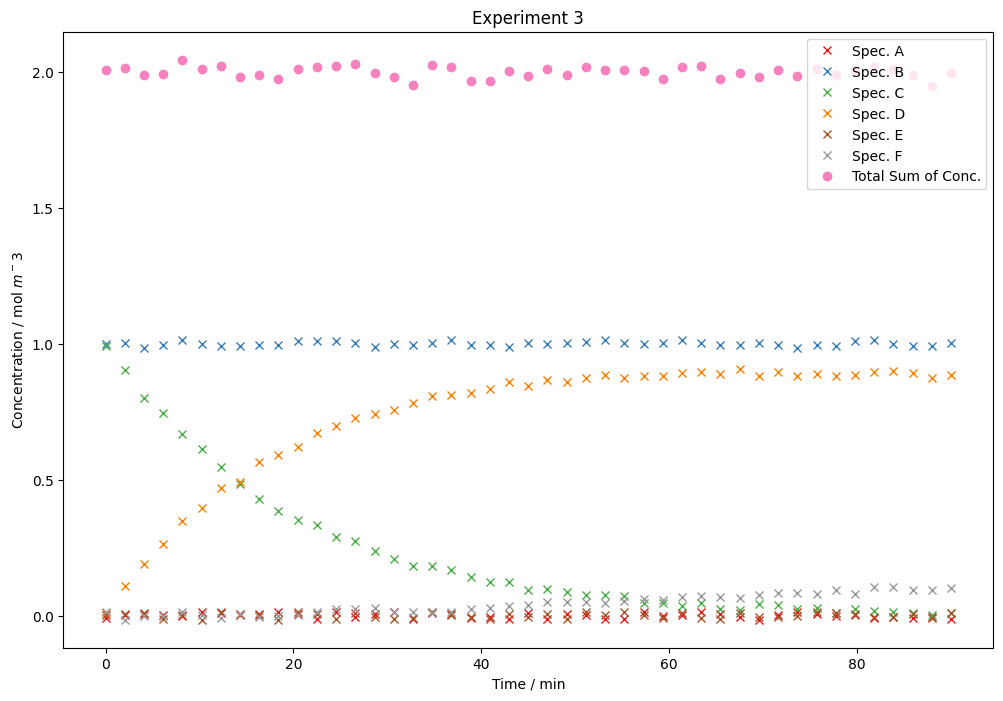

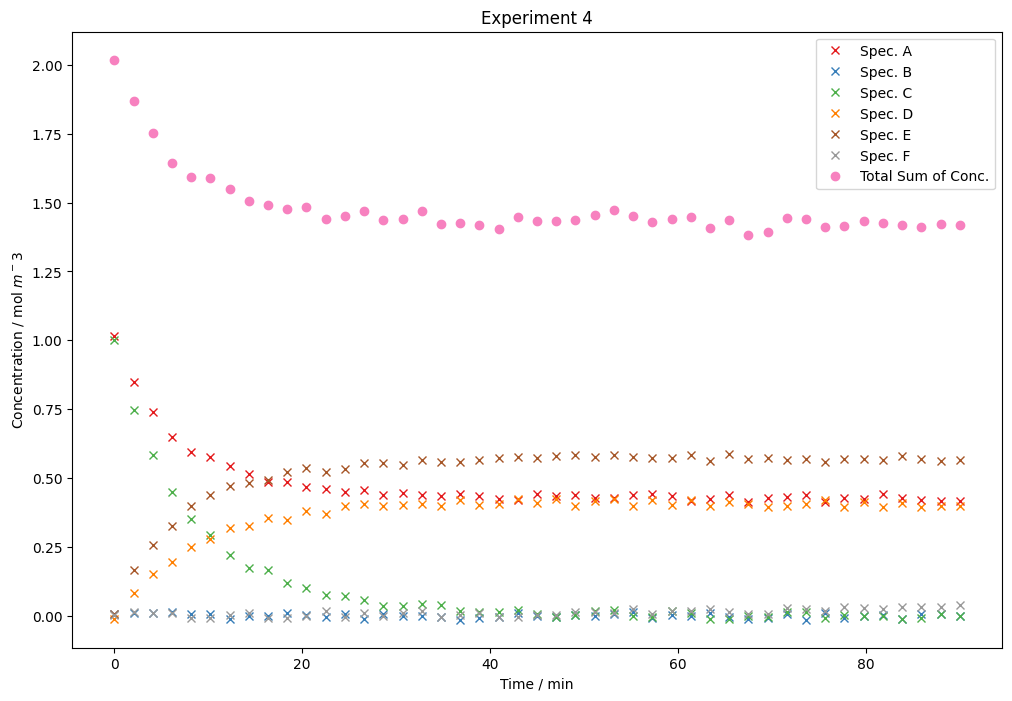

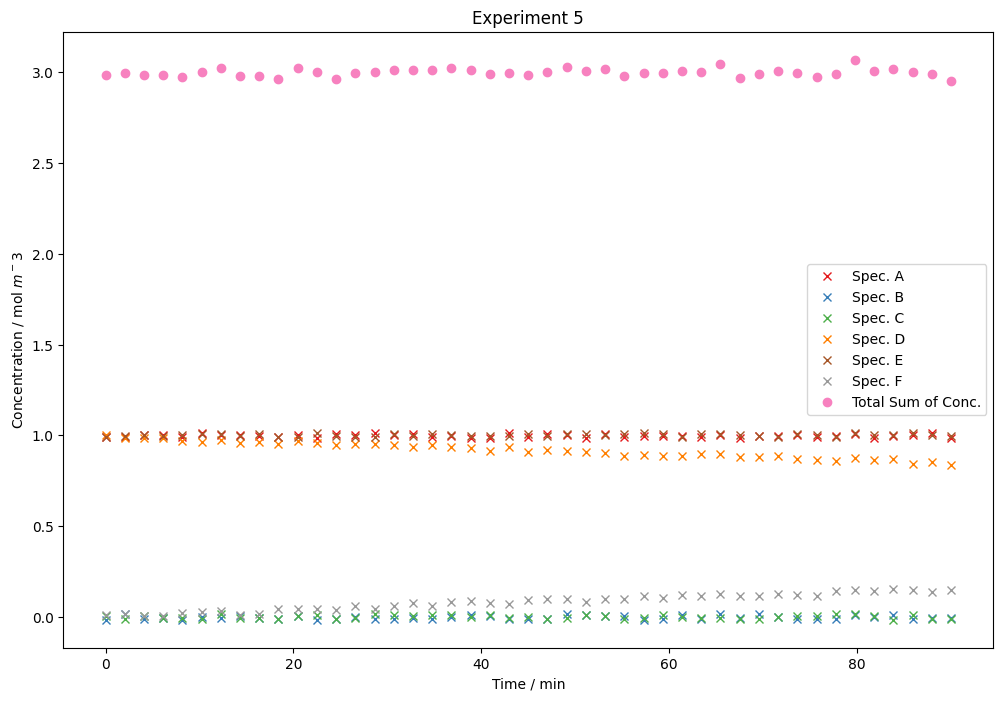

In [2]:
no_of_species = 6
speciescount = np.array(["A","B","C","D","E","F"])              # Naming Array for Legends in plotting
colors = colormaps.get_cmap('Set1')                            # Getting a colormap from library, personal preference and visibility
colordivider = np.array([0,0.15,0.3,0.5,0.7,0.99])               # Arrays with integers, to get the same colors for the same species in all diagrams

for i in range(no_of_exp):
    plt.subplots(figsize=(12,8))
    total_conc = np.zeros(45)
    for j in range(no_of_species):
        start = i * 270 + j *45                                         # starting point of each experimental series, 6 species times 45 measuring points equals 270 eperimental data points per experiment
        for p in range(45):
            total_conc[p] = total_conc[p] + ExperimentalData[start + p]
        plt.plot(exp_time[i], ExperimentalData[start : start + 45], 'x' , label = "Spec. " + speciescount[j], color = colors(colordivider[j]))
        plt.title("Experiment " + str(i))
        plt.xlabel("Time / min")
        plt.ylabel("Concentration / mol $m^-3$")
    
    plt.plot(exp_time[i], total_conc, 'o', label = 'Total Sum of Conc.', color = colors(0.8))
    plt.legend()
    plt.show()



# Deducing a Reaction Hypothesis:

The best Place to start is looking for Experiments with the least amount of converted species, because they enable us to make assumptions for Species Interactions.

### Experiment 5:

Experiment 5 shows Species D declining slightly, and an equal amount of Species F beeing formed. This leads to the hypothesis:
\begin{align}
    1D \rightarrow 1F
\end{align}

Also, there are the Species A and E as an Educt, wich are not consumed. Species B and C also show no accumulation over Time. This could mean that the Reactions 

\begin{align}
    xA \rightarrow yB \\
    xA \rightarrow yC \\
    xE \rightarrow yB \\
    xE \rightarrow yC \\
\end{align}
are not happening, wich we will use as our hypothesis for now.

### Experiment 2

Experiment 2 shows the same behavior as Experiment 5, but with just Species D as a possible Educt. This further strengthens the above formulated hypothesis, and shows, that the Reaction Paths 
\begin{equation}
    1A \rightarrow 1F
\end{equation}

\begin{equation}
    1E \rightarrow 1F
\end{equation}
from Experiment 5 are unlikely.

### Experiment 3:

Experiment 3 shows Species C beeing consumed, and forming Species D in a 1:1 Ratio. From 40 minutes on we can also see the Formation of Species F, wich is concurrent with our Hypothesis from Experiment 5. \
The newly formed Species D is slowly beeing consumed in the Formation of Species F
\begin{equation}
    1C \rightarrow 1D \rightarrow 1F
\end{equation}
In this Networking of Consecutive reactions, the Reaction from C to D seems to be much faster than the Reaction from D to F.

Also there is the Species B as a Educt, wich is not consumed. Therefor we hypothesize the following Reactions to be not taking place:
\begin{align}
    xB \rightarrow yX \\
    xB + yC \rightarrow XYZ 
\end{align}
Species B alone or in Combination with C has no reaction.

### Experiment 1

Experiment 1 shows the same Behavior for Species C,D and F as Experiment 3, but with only C as an Educt. This strenghtens all Hypothesis from Experiment 3.

### Experiment 4

Experiment 4 shows Species A and C as Educts, and Species D and E as formed Products. \
We know from before, that D can decay to Species F, but it is not distinguishable from general noise in this Experiment. B seems not to be formed at all.\
Species C gets fully consumed, Species A retains a concentration Level >0. \
This is also the first time the Total concentration changes, wich means some Rection has no 1:1 Ratio anymore. More Species is consumed than formed, the total Concentration goes from 2 $mol/m^3$ to about 1.5 $mol/m^3$.

We know from Experiment 5, that the Combination of Species A and E, A and D or Species E and D produce no Reaction. Therefor we can hypothesize, that E is not part of any further reaction and just gets formed. 

Experiment 3 and 1 showed a 1:1 Ratio for the Formation of D from C, yet here only half as much D as consumed C is formed. Species C must therefor be involved in the Formation of E. We hypothesize the following reactions happening here:

\begin{align}
    1A + 1C \rightarrow 1E\\
    1C  \rightarrow 1D\\
    1D \rightarrow 1F (slow)
\end{align}

### Experiment 0

Experiment 0 is the first Time B gets consumed, and the only time it is existing besides Species A. Therefor we can formulate the Hypothesis, that A and B together react to something.\ 
Because it has the highest starting Formation Speed, it is reasonable to think, C is beeing formed. The Ration would be 2:1.
\begin{equation}
    1A + 1B \rightarrow 1C
\end{equation}
C is beeing formed and after a Peak starts beeing consumed. This is most likely the Formation into D, seen in Experiments 1 and 3. \
Also C is involved in the Formation of E with Species A, wich explains the total Consumation of A, while B reatins a concentration >0.

## Summary 

The standing Hypothesis predicts the follwing Reaction Network:
\begin{align}
    1A + 1C \rightarrow 1 E\\
    1A + 1B \rightarrow 1 C\\
    1C \rightarrow 1 D\\
    1D \rightarrow 1 F\\
\end{align}

The Reaction from D to F is very slow. We can also conclude, that Reaction 1 is faster than Reaction 3 (seen in Experiment 4).

# Parameter Estimation

In [ ]:
def ode(t, c, k):
    """
    Calculate time derivatives of the ode for a batch STR
    Parameters
    ----------
    t: float
        time of the calculation;\\
    c: array
        concentration values at time t, size [nc]\\
    k: array
        kinetic coefficients for all reactions, size [nr]

    Returns
    -------
    dcdt: array
        time derivatives of the concentration, size [nc]
    """

    c = np.maximum(c, 0) # to avoid negative concentrations, which can cause problems with the power function, we set all negative values to 0. This is reasonable, as negative concentrations are not physically meaningful.
    
    # calculating reaction rates
    r0 = k[0] * c[0] * c[2]
    r1 = k[1] * c[0] * c[1]
    r2 = k[2] * c[2]
    r3 = k[3] * c[3]

    #calculating the derivatives
    dcdt = np.zeros_like(c)         # initialises an array filled with zeros with the exact same shape as the array of given concentrations c
    dcdt[0] = - r0 -r1 
    dcdt[1] = - r1
    dcdt[2] = + r1 - r2 - r0
    dcdt[3] = + r2 - r3
    dcdt[4] = + r0
    dcdt[5] = + r3
    return dcdt

In [4]:
def solver(t, init_conc, k):
    """
    Simulate single experiment using solve_ivp.
    Parameters
    ----------
    t: array
       array with the time points of the simulation, size [nt]\\
    init_conc: array
        initial concentrations, size [nc]\\
    k: array
        kinetic coefficients for all reactions, size [nr]

    Returns
    -------
    c_sol: array
        concentration values at times defined by t, size [nc, nt]
    """
    solution = scp.solve_ivp(fun=ode, t_span=[t[0],t[-1]], y0=init_conc, method = 'LSODA', t_eval=t, args=[k])
    return solution.y


In [5]:
def sim_multiple_exps(times, k0, k1, k2, k3, c_inits):
    """
    Simulate results for n experiments with nc components and 4 reactions. Each experiment has nt_i entries. 
    Note: This had to be modified from the example Code, because in this Case there are (presumably) 4 Reactions.

    Parameters
    ----------
    times: list
        List of arrays with times of sampling for each experiment, size [n][nt_i,]\\
    k0: float
        Kinetic parameter of first reaction\\
    k1: float
        Kinetic parameter of second reaction\\
    k2: float
        Kinetic parameter of third reaction\\
    k3: float
        Kinetic Paramtere of fourth reaction\\
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]\\


    Returns
    -------
    sim concs: list
        List of arrays with calculated concentration values, size[n][nc, nt_i].
    """

    sim_concs = []
    k = [k0, k1, k2, k3]

    # iterate over all experiments
    nex = len(times)
    for i in np.arange(0, nex):
        # assign c and t to run simulation
        c_0 = c_inits[i]
        t = times[i]

        # run simulation for one experiment
        conc = solver(t, c_0, k)
        sim_concs.append(conc)
    return sim_concs

### limfit for Parameter Estimation

In [6]:
def estimator(params, t, initial_concs, actual_data):
    """
    Minimizes the Difference between simulated Data and given experimental Data through iteration, changing the parameters to fit every Iteration

    Parameters
    -----------
    params:
        the parameters we want to change and fit through iteration\\
    t:
        Measurements times of the experiments, in the Format of a List of arrays\\
    actual_data:
        actual Data from the experiments, List of arrays \\
    initial_concs:
        initial concentrations of each experiment, List of arrays\\

    Returns
    ----------
    diff:
        difference between simulated result and actual Data
    """

    sim_res = sim_multiple_exps(t, params["k0"], params["k1"], params["k2"], params["k3"], initial_concs) # returns a List of arrayss, with the Results for experiment 0-5
    flat_sim_res = np.array([]) # empty array to store simulated Data in for comparison with experimental Data
    nex = len(t)
    for i in np.arange(0,nex):
        flat_sim_res = np.append(flat_sim_res, sim_res[i])

    return flat_sim_res - actual_data

In [7]:
import lmfit

params = lmfit.Parameters()
params.add('k0', value = 0.5, min = 0, max = 10, vary = True)
params.add('k1', value = 0.5, min = 0, max = 10, vary = True)
params.add('k2', value = 0.5, min = 0, max = 10, vary = True)
params.add('k3', value = 0.5, min = 0, max = 10, vary = True)

minimized_res = lmfit.Minimizer(estimator, params, fcn_args=(exp_time, init_c_val, ExperimentalData))
result = minimized_res.minimize()
lmfit.report_fit(result)

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 42
    # data points      = 1620
    # variables        = 4
    chi-square         = 0.26016893
    reduced chi-square = 1.6100e-04
    Akaike info crit   = -14145.3010
    Bayesian info crit = -14123.7403
[[Variables]]
    k0:  0.09602086 +/- 5.4796e-04 (0.57%) (init = 0.5)
    k1:  0.19748941 +/- 0.00182128 (0.92%) (init = 0.5)
    k2:  0.05034466 +/- 1.8617e-04 (0.37%) (init = 0.5)
    k3:  0.00157815 +/- 1.5859e-05 (1.00%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(k0, k2) = +0.4511
    C(k0, k1) = +0.2905
    C(k2, k3) = +0.1013


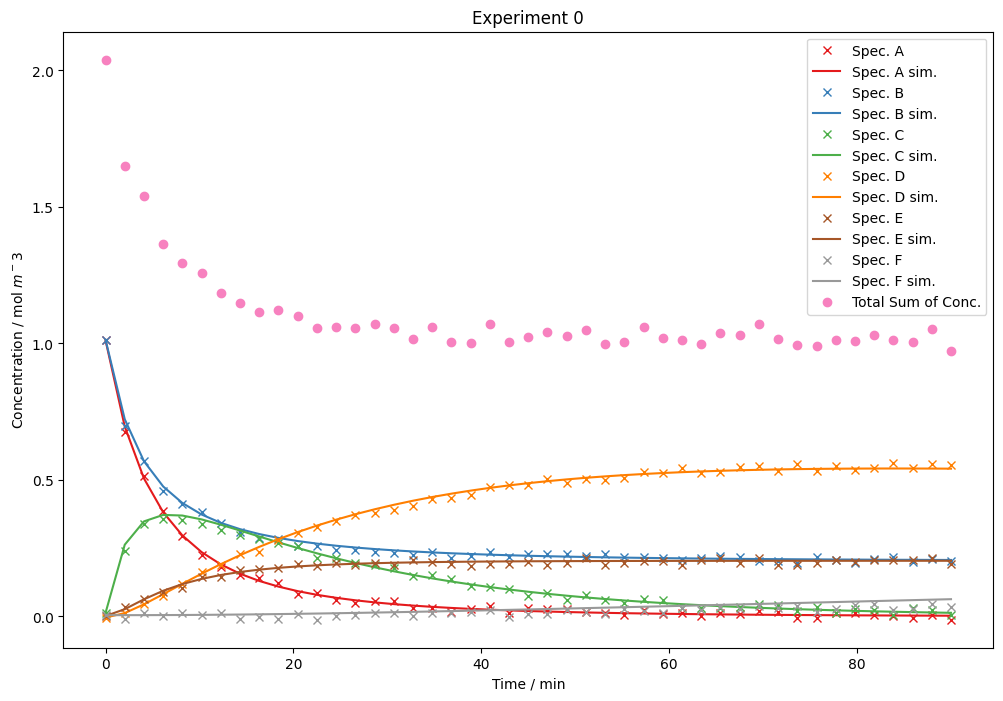

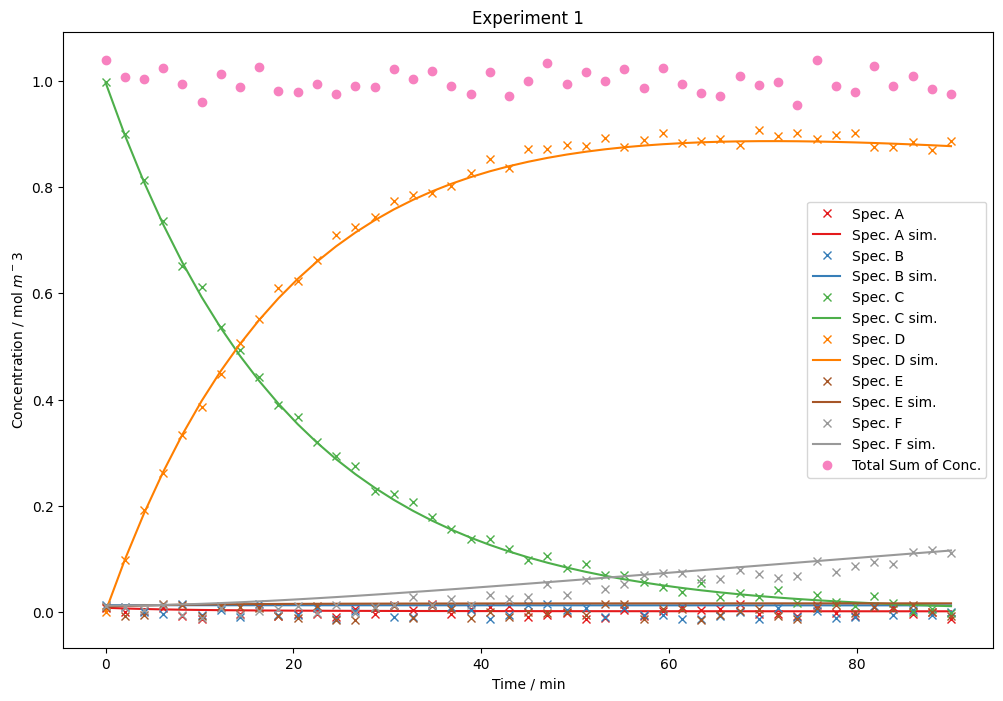

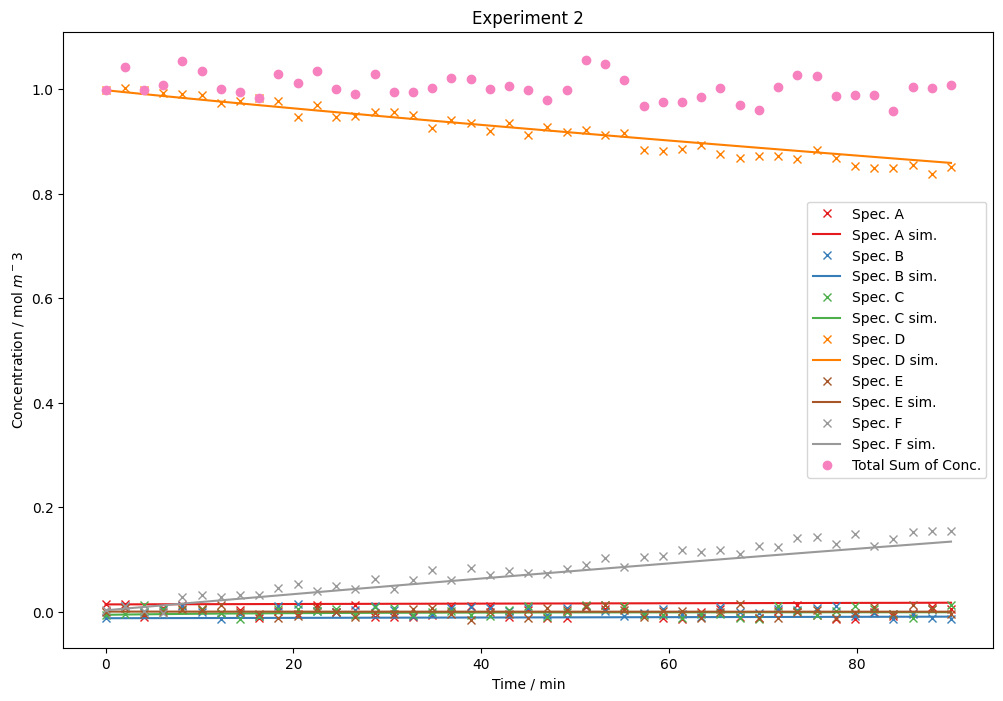

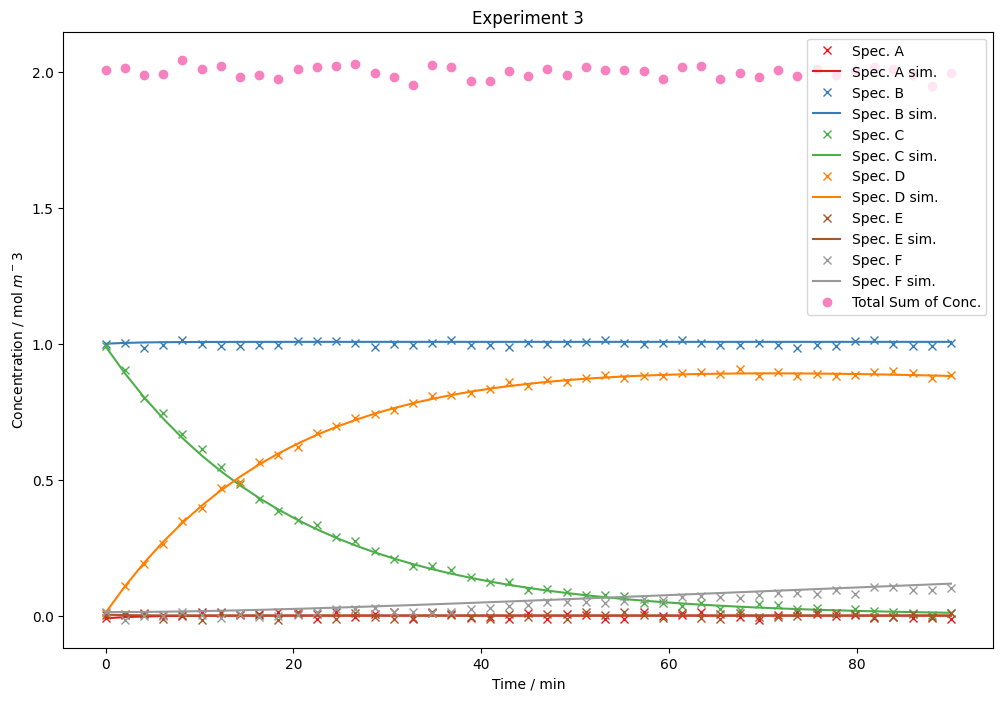

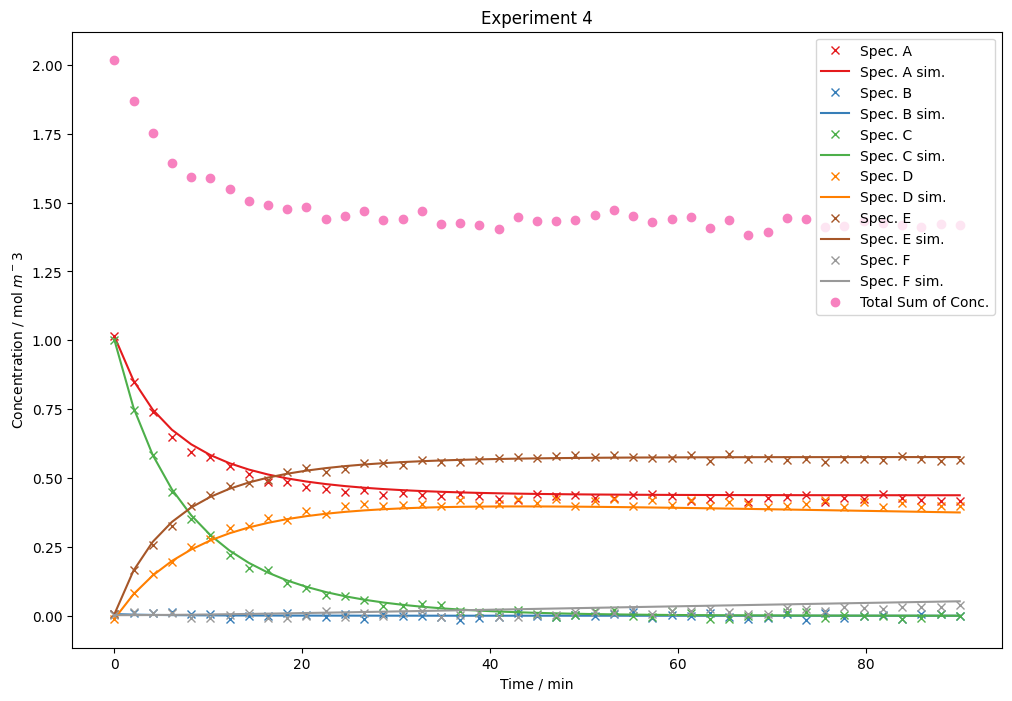

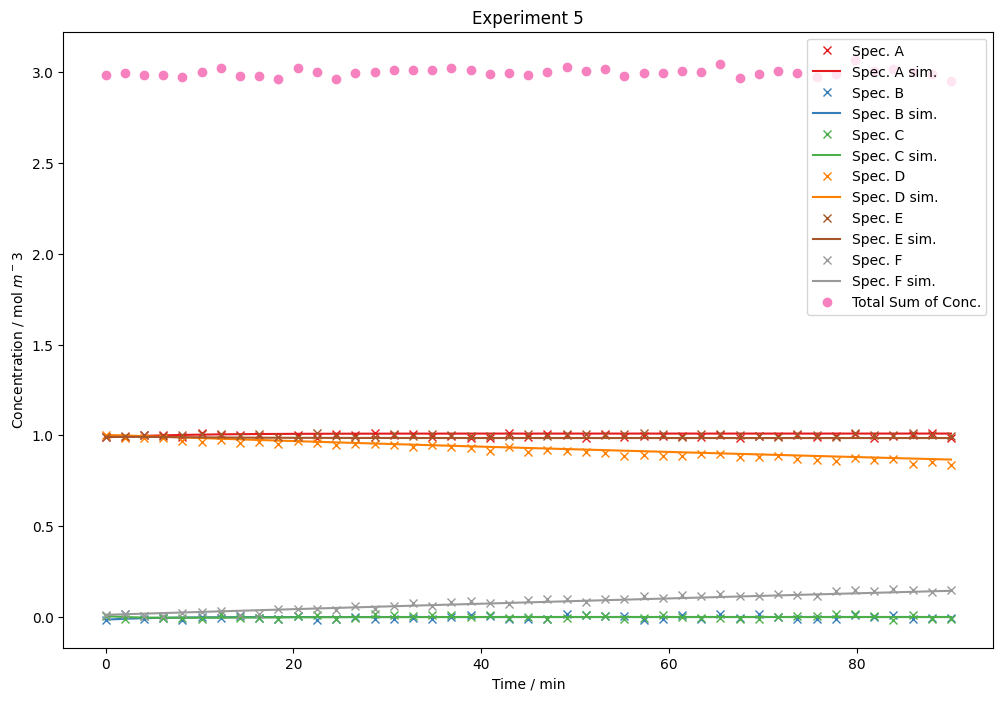

In [8]:
bestfit_res = sim_multiple_exps(exp_time, result.params["k0"], result.params["k1"], result.params["k2"], result.params["k3"], init_c_val)

for i in range(no_of_exp):
    plt.subplots(figsize=(12,8))
    total_conc = np.zeros(45)
    for j in range(no_of_species):
        start = i * 270 + j *45                                         # starting point of each experimental series, 6 species times 45 measuring points equals 270 eperimental data points per experiment
        for p in range(45):
            total_conc[p] = total_conc[p] + ExperimentalData[start + p]
        plt.plot(exp_time[i], ExperimentalData[start : start + 45], 'x' , label = "Spec. " + speciescount[j], color = colors(colordivider[j]))
        plt.plot(exp_time[i], bestfit_res[i][j], label = "Spec. " + speciescount[j] + " sim.", color = colors(colordivider[j]))
        plt.title("Experiment " + str(i))
        plt.xlabel("Time / min")
        plt.ylabel("Concentration / mol $m^-3$")
    
    plt.plot(exp_time[i], total_conc, 'o', label = 'Total Sum of Conc.', color = colors(0.8))
    plt.legend()
    plt.show()

# Plausibility Check

Because we cannot plainly trust computer output, we need to test the Results for plausability and validate them. The first Eye-test (above) seems promising, there are no significant deviations between the simulated Results and the given experimental Data.

Because an eye-Test is susceptible to human Error, we check for the average mathematical Error. For this, we have chosen the coefficient of determination $R^2$ and the root mean square error (RMSE).

## $R^2$

In [9]:
# Calculating the coefficient of determination for each species in each experiment individually
def R2_for_each_exp(exp_concentration, sim_res):
    '''
    Calculates the coefficient of determination for each species in each experiment individually

    Parameters
    ----------
    exp_concentration: List
        List of arrays with the experimental concentrations for each species in each experiment, size: [n_experiments][n_species, n_measurements]
    sim_res: List
        List of arrays with the simulated results for each species in each experiment, size: [n_experiments][n_species, n_measurements]

    Returns
    ----------
    R2_for_each: List
        List of stirngs with the result for each Species and Experiment listet for better readability, size: [n_experiments_times_species]
    '''
    R2_for_each = []
    for i in range(len(exp_concentration)):                                                         # Number of Experiments
        for j in range(len(exp_concentration[i])):                                                  # Species in the Experiment
            c_med = np.mean(exp_concentration[i][j])                                                # calculates the mean value y of species j in Experiment i
            #calculation of R^2, for in depth explanation look up definition of coefficient of determination
            SQR = np.sum((exp_concentration[i][j]-sim_res[i][j])**2)
            SQT = np.sum((exp_concentration[i][j]-c_med)**2)
            R2  = 1 - (SQR/SQT)
            R2_for_each = np.append(R2_for_each, "Experiment " + str(i) + ", Species " + speciescount[j] + ": " + str(R2))
    return R2_for_each

# Calculating the coefficient of determination for all Measuring points over all Experiments and species together
def R2_total(sim_data, actual_data):
    '''
    Calculate the total coefficient of determination for all measuring points over all Experiments combined.
    Parameters
    ----------
    sim_data: list
        List of arrays with the simulated results for each species and experiment, size [n_experiments][n_species, n_measurements]\\
    actual_data: list
        flat list (1D) with all experimentally measured values, size [n_measurements_total]
    
    Returns
    ----------
    R2_total: float
        value for the coefficient of determination over all experiments, size: 1
    '''
    sim_res_flat = []
    for i in range(len(sim_data)):
        sim_res_flat = np.append(sim_res_flat, sim_data[i])
    SQR_tot = np.sum((actual_data - sim_res_flat)**2 )
    SQT_tot = np.sum((actual_data - np.mean(actual_data))**2)
    R2_total = 1 - (SQR_tot/SQT_tot)
    return R2_total

print(R2_total(bestfit_res, ExperimentalData))
print(R2_for_each_exp(exp_conc, bestfit_res))

0.9987735950329811
['Experiment 0, Species A: 0.9978683223552729'
 'Experiment 0, Species B: 0.9957659536341572'
 'Experiment 0, Species C: 0.9902208331058108'
 'Experiment 0, Species D: 0.9963476335170011'
 'Experiment 0, Species E: 0.9667945354267933'
 'Experiment 0, Species F: -0.26325299764574184'
 'Experiment 1, Species A: -0.057840241728573716'
 'Experiment 1, Species B: -2.1115117491503206'
 'Experiment 1, Species C: 0.9988417395387332'
 'Experiment 1, Species D: 0.9975104427995404'
 'Experiment 1, Species E: -2.4078720020099227'
 'Experiment 1, Species F: 0.7638510279924849'
 'Experiment 2, Species A: -3.0089678230435197'
 'Experiment 2, Species B: -2.1754708789168435'
 'Experiment 2, Species C: -0.09982130606742867'
 'Experiment 2, Species D: 0.9395326663168428'
 'Experiment 2, Species E: -0.002113807744213325'
 'Experiment 2, Species F: 0.889591220471636'
 'Experiment 3, Species A: -0.018384220306060017'
 'Experiment 3, Species B: -0.7854376255101063'
 'Experiment 3, Species 

We observe values near 1 for each experiment–species combination where the species concentration is not approximately constant throughout the experiment. This is because the coefficient of determination is undefined for a constant set of measured values (as it would require division by zero by definition).\
The only reason division by zero does not occur is that measurement errors exist even for nominally constant concentrations, resulting in slight variation. Nonetheless, for measurements with near-constant or predominantly constant values, the coefficient of determination is not meaningful.\
In cases where the coefficient of determination is applicable, we almost always obtain values above 95%, which indicates a very good fit.

## RMSE

In [10]:
def RMSE(exp_concentration, sim_res):
    '''
    Calculates the RMSE for each species in each experiment individually

    Parameters
    ----------
    exp_concentration: List
        List of arrays with the experimental concentrations for each species in each experiment, size: [n_experiments][n_species, n_measurements]
    sim_res: List
        List of arrays with the simulated results for each species in each experiment, size: [n_experiments][n_species, n_measurements]

    Returns
    ----------
    RMSE_for_each: List
        List of stirngs with the result for each Species and Experiment listet for better readability, size: [n_experiments_times_species]
    '''
    RMSE_for_each = []

    for i in range(len(exp_concentration)):                                             # Number of Experiments
        for j in range(len(exp_concentration[i])):                                                  # Species in the Experiment
            #calculation of RMSE, for in depth explanation look up definition of coefficient of determination
            RMSE  = np.sqrt(np.sum((exp_concentration[i][j] - sim_res[i][j])**2)/len(exp_concentration[i][j]))
            RMSE_for_each = np.append(RMSE_for_each, "Experiment " + str(i) + ", Species " + speciescount[j] + ": " + str(RMSE))
    return RMSE_for_each

def RMSE_total(sim_data, actual_data):
    '''
    Calculates the total RMSE for all measuring points over all Experiments combined.

    Parameters
    ----------
    sim_data: list
        List of arrays with the simulated results for each species and experiment, size [n_experiments][n_species, n_measurements]\\
    actual_data: list
        flat list (1D) with all experimentally measured values, size [n_measurements_total]
    
    Returns
    ----------
    RMSE_total: float
        value for the coefficient of determination over all experiments, size: 1
    '''
    sim_res_flat = []
    for i in range(len(sim_data)):                                                              # flattens the simulated Data in a 1D array
        sim_res_flat = np.append(sim_res_flat, sim_data[i])
    RMSE_tot  = np.sqrt(np.sum((actual_data - sim_res_flat)**2)/len(actual_data))
    return RMSE_tot

print(RMSE(exp_conc, bestfit_res))
print(RMSE_total(bestfit_res, ExperimentalData))

['Experiment 0, Species A: 0.009001220922623798'
 'Experiment 0, Species B: 0.009654231283690626'
 'Experiment 0, Species C: 0.011020145877841092'
 'Experiment 0, Species D: 0.01000370609020663'
 'Experiment 0, Species E: 0.008461940070748696'
 'Experiment 0, Species F: 0.0162738475262072'
 'Experiment 1, Species A: 0.008342574305175881'
 'Experiment 1, Species B: 0.015899436523083663'
 'Experiment 1, Species C: 0.008930107109472282'
 'Experiment 1, Species D: 0.011824682036452396'
 'Experiment 1, Species E: 0.017692320797254895'
 'Experiment 1, Species F: 0.017794482631063913'
 'Experiment 2, Species A: 0.01880236337937332'
 'Experiment 2, Species B: 0.013953150922795863'
 'Experiment 2, Species C: 0.008587567811146278'
 'Experiment 2, Species D: 0.012014967565102341'
 'Experiment 2, Species E: 0.007854327929072133'
 'Experiment 2, Species F: 0.015057789705392961'
 'Experiment 3, Species A: 0.009226789097058218'
 'Experiment 3, Species B: 0.010447400597451261'
 'Experiment 3, Species 

The root mean squared error shows no significant variation between experiments, in contrast to the coefficient of determination. This is because it accounts only for the total absolute error between the measured values and the simulated results.

It shows that, on average, our simulation deviates by approximately 0.0121 mol m⁻³. This deviation is very small and can, to a significant extent, be attributed to measurement uncertainty.

Combined with the coefficient of determination calculated above, this demonstrates that the simulated results closely track the experimental measurements in both the relative variation and absolute values. We therefore consider the simulated results to be validated.

# Potential improvement of simulated Data with additional fit for rate order

In [ ]:
def ode_with_n(t, c, k, n):
    """
    Calculate time derivatives of the ode for a batch STR
    Parameters
    ----------
    t: float
        time of the calculation;\\
    c: array
        concentration values at time t, size [nc]\\
    k: array
        kinetic coefficients for all reactions, size [nr]\\
    n: array
        reaction rates for alle species and all reactions, sizen [n_sp]

    Returns
    -------
    dcdt: array
        time derivatives of the concentration, size [nc]
    """

    c = np.maximum(c, 0) # to avoid negative concentrations, which can cause problems with the power function, we set all negative values to 0. This is reasonable, as negative concentrations are not physically meaningful.

    # calculating reaction rates
    r0 = k[0] * c[0]**n[0] * c[2]**n[1]
    r1 = k[1] * c[0]**n[2] * c[1]**n[3]
    r2 = k[2] * c[2]**n[4]
    r3 = k[3] * c[3]**n[5]

    #calculating the derivatives
    dcdt = np.zeros_like(c)         # initialises an array filled with zeros with the exact same shape as the array of given concentrations c
    dcdt[0] = - r0 -r1 
    dcdt[1] = - r1
    dcdt[2] = + r1 - r2 - r0
    dcdt[3] = + r2 - r3
    dcdt[4] = + r0
    dcdt[5] = + r3
    return dcdt

def solver_with_n(t, init_conc, k, n):
    """
    Simulate single experiment using solve_ivp.
    Parameters
    ----------
    t: array
       array with the time points of the simulation, size [nt]\\
    init_conc: array
        initial concentrations, size [nc]\\
    k: array
        kinetic coefficients for all reactions, size [nr]\\
    n: array
        reaction rates for alle species and all reactions, sizen [n_sp]

    Returns
    -------
    c_sol: array
        concentration values at times defined by t, size [nc, nt]
    """
    solution = scp.solve_ivp(fun=ode_with_n, t_span=[t[0],t[-1]], y0=init_conc, method = 'LSODA', t_eval=t, args=[k, n])
    return solution.y

def sim_multiple_exps_with_n(times, k0, k1, k2, k3, n0, n1, n2, n3, n4, n5, c_inits):
    """
    Simulate results for n experiments with nc components and 4 reactions. Each experiment has nt_i entries. 
    Note: This had to be modified from the example Code, because in this Case there are (presumably) 4 Reactions.

    Parameters
    ----------
    times: list
        List of arrays with times of sampling for each experiment, size [n][nt_i,]\\
    k0: float
        Kinetic parameter of first reaction\\
    k1: float
        Kinetic parameter of second reaction\\
    k2: float
        Kinetic parameter of third reaction\\
    k3: float
        Kinetic Paramtere of fourth reaction\\
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]\\
    n0: float
        reaction rate of first species first reaction
    n1: float
        reaction rate of second species first reaction
    n2: float
        reaction rate of first species second reaction
    n3: float
        reaction rate of second species second reaction
    n4: float
        reaction rate of first species third reaction
    n5: float
        reaction rate of first species fourth reaction

    Returns
    -------
    sim concs: list
        List of arrays with calculated concentration values, size[n][nc, nt_i].
    """

    sim_concs = []
    k = [k0, k1, k2, k3]
    n = [n0, n1, n2, n3, n4, n5]

    # iterate over all experiments
    nex = len(times)
    for i in np.arange(0, nex):
        # assign c and t to run simulation
        c_0 = c_inits[i]
        t = times[i]

        # run simulation for one experiment
        conc = solver_with_n(t, c_0, k, n)
        sim_concs.append(conc)
    return sim_concs

def estimator_with_n(params, t, initial_concs, actual_data):
    """
    Minimizes the Difference between simulated Data and given experimental Data through iteration, changing the parameters to fit every Iteration

    Parameters
    -----------
    params:
        the parameters we want to change and fit through iteration\\
    t:
        Measurements times of the experiments, in the Format of a List of arrays\\
    actual_data:
        actual Data from the experiments, List of arrays \\
    initial_concs:
        initial concentrations of each experiment, List of arrays\\

    Returns
    ----------
    diff:
        difference between simulated result and actual Data
    """

    sim_res = sim_multiple_exps_with_n(t, params["k0"], params["k1"], params["k2"], params["k3"], params["n0"], params["n1"], params["n2"], params["n3"], params["n4"], params["n5"], initial_concs) # returns a List of arrayss, with the Results for experiment 0-5
    flat_sim_res = np.array([]) # empty array to store simulated Data in for comparison with experimental Data
    nex = len(t)
    for i in np.arange(0,nex):
        flat_sim_res = np.append(flat_sim_res, sim_res[i])

    return flat_sim_res - actual_data

# We set the starting values for k to the vefore fitted results, to give the solver a better starting point and hence hopefully faster convergence. For the reaction rates n, we set the starting values to 1, which is the value for a reaction of order 1, which is a common case. 
# We also set the boundaries for n to 0 and 5, as negative reaction orders are not physically meaningful, and reaction orders above 5 are very uncommon and would make the model unnecessarily complex.
params_with_n = lmfit.Parameters()
params_with_n.add('k0', value = result.params['k0'], min = 0, max = 10, vary = True)
params_with_n.add('k1', value = result.params['k1'], min = 0, max = 10, vary = True)
params_with_n.add('k2', value = result.params['k2'], min = 0, max = 10, vary = True)
params_with_n.add('k3', value = result.params['k3'], min = 0, max = 10, vary = True)
params_with_n.add('n0', value = 1, min = 0, max = 5, vary = True)
params_with_n.add('n1', value = 1, min = 0, max = 5, vary = True)
params_with_n.add('n2', value = 1, min = 0, max = 5, vary = True)
params_with_n.add('n3', value = 1, min = 0, max = 5, vary = True)
params_with_n.add('n4', value = 1, min = 0, max = 5, vary = True)
params_with_n.add('n5', value = 1, min = 0, max = 5, vary = True)

minimized_res_with_n = lmfit.Minimizer(estimator_with_n, params_with_n, fcn_args=(exp_time, init_c_val, ExperimentalData))
result_with_n = minimized_res_with_n.minimize()
lmfit.report_fit(result_with_n)

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 137
    # data points      = 1620
    # variables        = 10
    chi-square         = 0.20507696
    reduced chi-square = 1.2738e-04
    Akaike info crit   = -14518.7732
    Bayesian info crit = -14464.8714
[[Variables]]
    k0:  0.09657274 +/- 4.6898e-04 (0.49%) (init = 0.09602086)
    k1:  0.19012876 +/- 0.00420102 (2.21%) (init = 0.1974894)
    k2:  0.04995261 +/- 3.3008e-04 (0.66%) (init = 0.05034466)
    k3:  0.00194509 +/- 2.4936e-05 (1.28%) (init = 0.001578151)
    n0:  1.00953665 +/- 0.01788741 (1.77%) (init = 1)
    n1:  0.98831893 +/- 0.01447583 (1.46%) (init = 1)
    n2:  1.14417084 +/- 0.04009978 (3.50%) (init = 1)
    n3:  0.74907134 +/- 0.07105282 (9.49%) (init = 1)
    n4:  1.00740538 +/- 0.00728585 (0.72%) (init = 1)
    n5:  2.21332675 +/- 0.08224815 (3.72%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(k0, k2) = -0.9458
    C(n2, n3) = -0.8868
    C(k2, n4) = +0.857

In [14]:
bestfit_res_with_n = sim_multiple_exps_with_n(exp_time, result_with_n.params["k0"], result_with_n.params["k1"], result_with_n.params["k2"], result_with_n.params["k3"], result_with_n.params["n0"], result_with_n.params["n1"], result_with_n.params["n2"], result_with_n.params["n3"], result_with_n.params["n4"], result_with_n.params["n5"], init_c_val)
print(R2_for_each_exp(exp_conc, bestfit_res_with_n))
print(R2_total(bestfit_res_with_n, ExperimentalData))
print(RMSE(exp_conc, bestfit_res_with_n))
print(RMSE_total(bestfit_res_with_n, ExperimentalData))

['Experiment 0, Species A: 0.99776158249729'
 'Experiment 0, Species B: 0.9941073302456321'
 'Experiment 0, Species C: 0.9902149494373399'
 'Experiment 0, Species D: 0.995182297222858'
 'Experiment 0, Species E: 0.9590186603467095'
 'Experiment 0, Species F: 0.6563368100652274'
 'Experiment 1, Species A: -0.06048417917263382'
 'Experiment 1, Species B: -2.0862722575542674'
 'Experiment 1, Species C: 0.9990651580787371'
 'Experiment 1, Species D: 0.9983158179883287'
 'Experiment 1, Species E: -2.3709913663631745'
 'Experiment 1, Species F: 0.8778925625184034'
 'Experiment 2, Species A: -2.369024008539525'
 'Experiment 2, Species B: -2.7127236458529724'
 'Experiment 2, Species C: -0.5270199550946126'
 'Experiment 2, Species D: 0.9574223291918541'
 'Experiment 2, Species E: -0.005435748073256974'
 'Experiment 2, Species F: 0.9637144352240268'
 'Experiment 3, Species A: -1.275305782257576'
 'Experiment 3, Species B: -0.0030728892254268114'
 'Experiment 3, Species C: 0.9988975100798473'
 'E

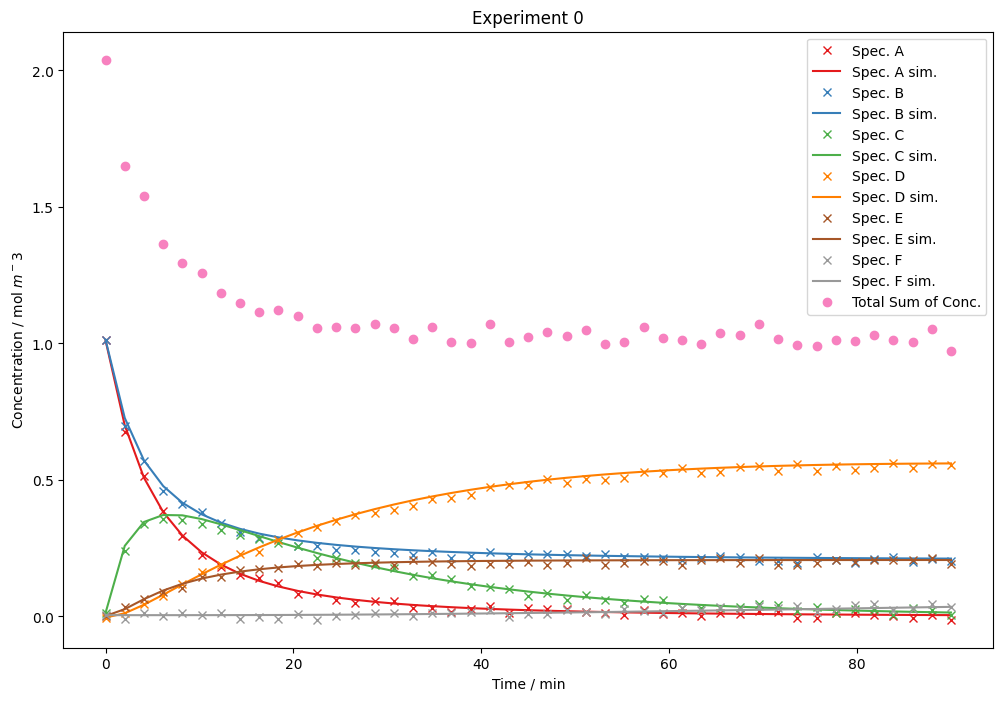

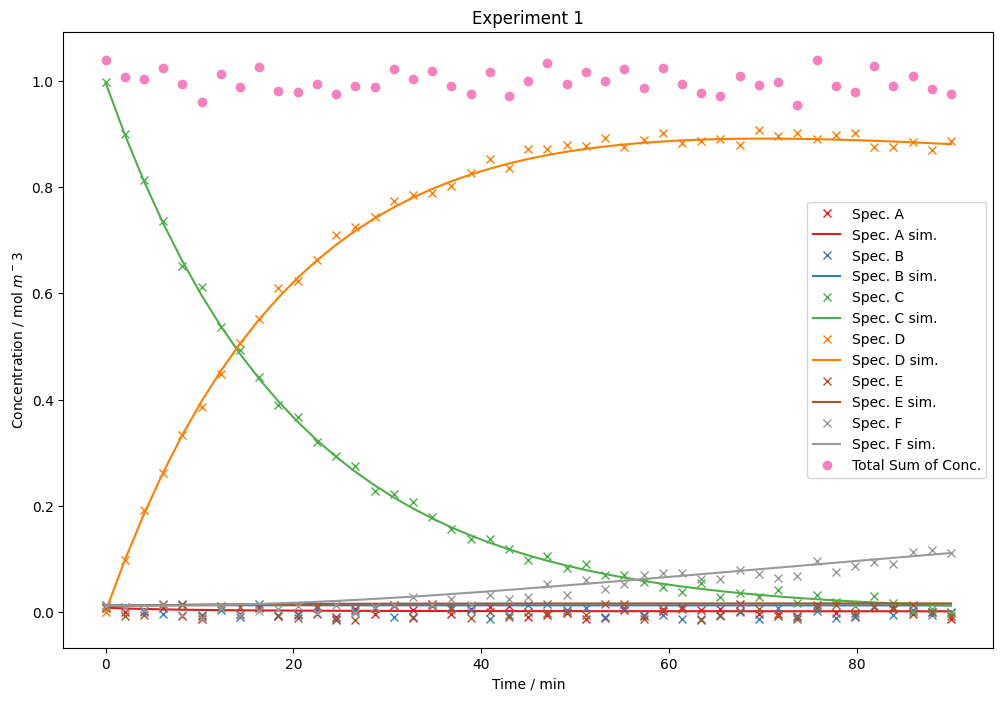

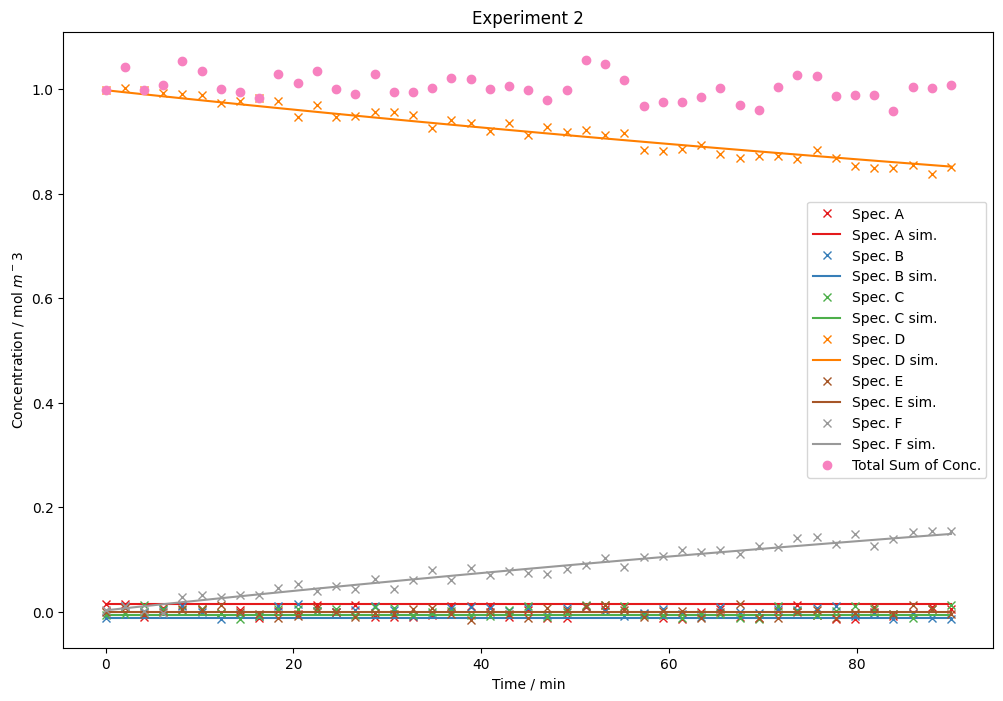

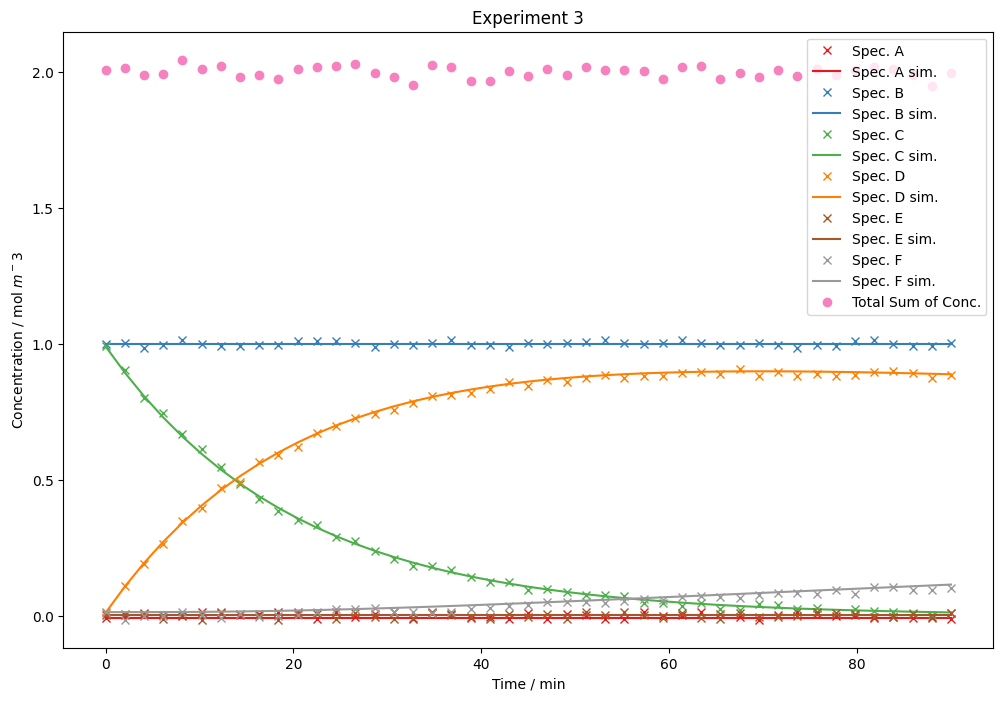

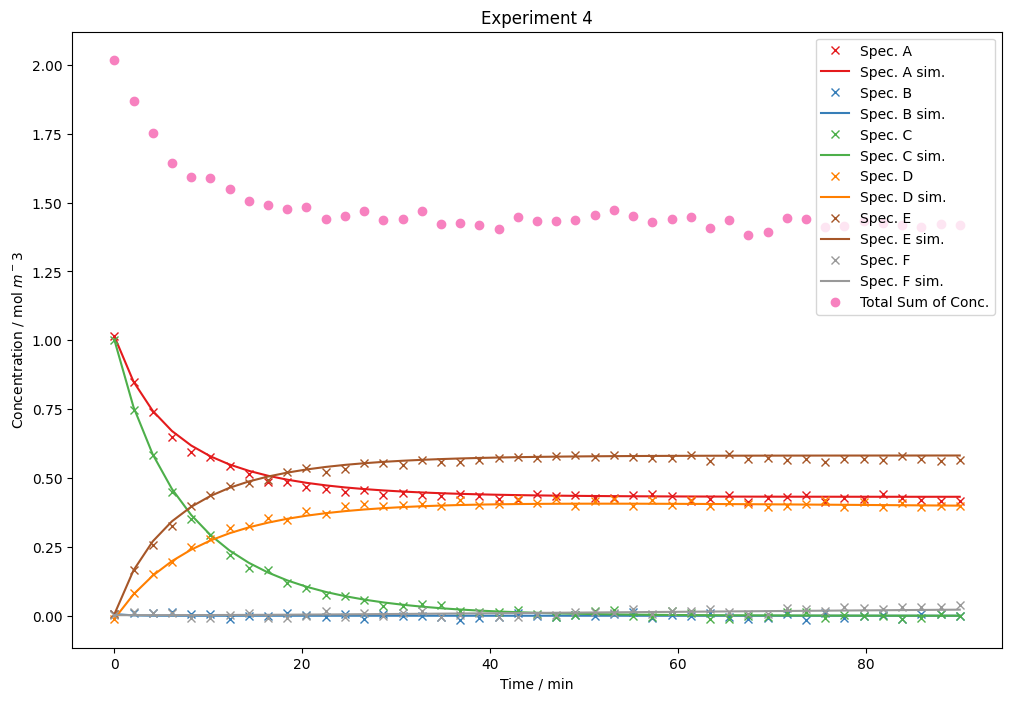

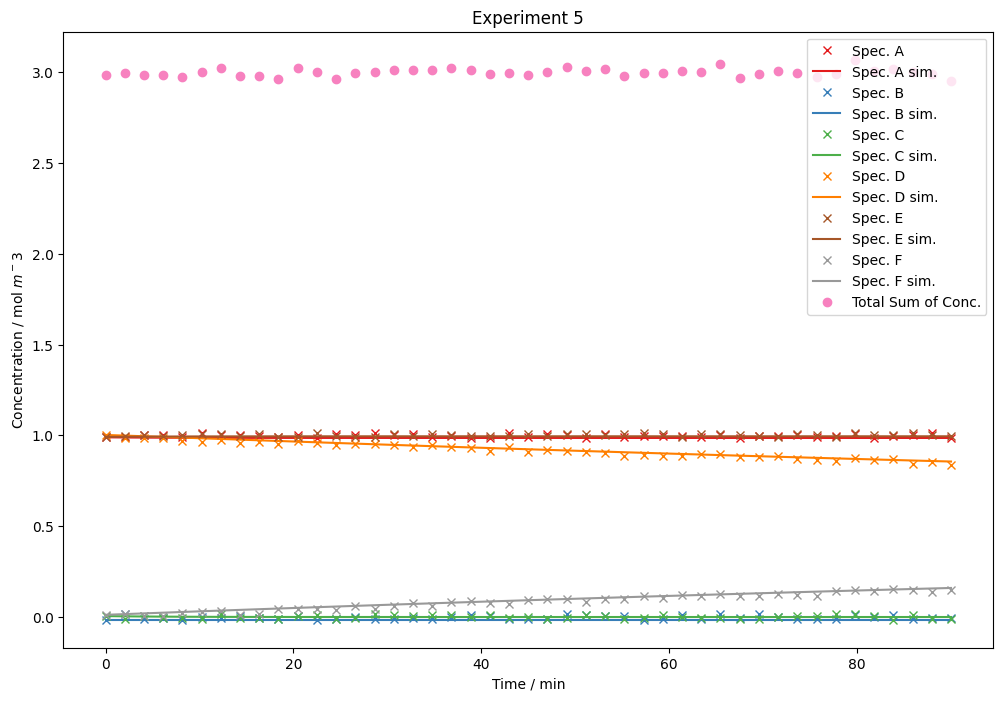

In [15]:
for i in range(no_of_exp):
    plt.subplots(figsize=(12,8))
    total_conc = np.zeros(45)
    for j in range(no_of_species):
        start = i * 270 + j *45                                         # starting point of each experimental series, 6 species times 45 measuring points equals 270 eperimental data points per experiment
        for p in range(45):
            total_conc[p] = total_conc[p] + ExperimentalData[start + p]
        plt.plot(exp_time[i], ExperimentalData[start : start + 45], 'x' , label = "Spec. " + speciescount[j], color = colors(colordivider[j]))
        plt.plot(exp_time[i], bestfit_res_with_n[i][j], label = "Spec. " + speciescount[j] + " sim.", color = colors(colordivider[j]))
        plt.title("Experiment " + str(i))
        plt.xlabel("Time / min")
        plt.ylabel("Concentration / mol $m^-3$")
    
    plt.plot(exp_time[i], total_conc, 'o', label = 'Total Sum of Conc.', color = colors(0.8))
    plt.legend()
    plt.show()

The Results from the additional fitting of the reaction orders n0-n5 show an increase in all the statistical measurements for fit quality. \
This shows, that the implementation improves the accuracy of the simulated Data. In Comparison with the fit for purely the kinetic constants, we get a slight improvement.\
This is because we already got a very good fit with purely the kinetic constants, leaving little room for further improvement. This is also shown in the little variation of k values in comparison to the first simulation.

It also makes a lot of sense to first vary the kinetic constant as a parameter, because it has a bigger impact on the Solution of the reaction Network. 

This is also made clear, if you start the solver with values of 1 for all reaction rates k and let n be fit to the values. This leads to very unrealistic values of n for Reaction 3 and 4, with reaction 4 having a deviation of +- 12882.3667 (257647.33%).

This value is far off anything reasonable, so it should be disregarded as a meaningfull result. The Result for chi squared also is at 110.181909, showing a low fit quality. The values for $R^2$ (0.48) and the RMSE (0.26) are also much worse than the Results for the variation of only k.

In [17]:
def ode_with_only_n(t, c, n):
    """
    Calculate time derivatives of the ode for a batch STR
    Parameters
    ----------
    t: float
        time of the calculation;\\
    c: array
        concentration values at time t, size [nc]\\
    n: array
        reaction rates for alle species and all reactions, sizen [n_sp]

    Returns
    -------
    dcdt: array
        time derivatives of the concentration, size [nc]
    """

    c = np.maximum(c, 0) # to avoid negative concentrations, which can cause problems with the power function, we set all negative values to 0. This is reasonable, as negative concentrations are not physically meaningful.

    # calculating reaction rates
    r0 = 1 * c[0]**n[0] * c[2]**n[1]
    r1 = 1 * c[0]**n[2] * c[1]**n[3]
    r2 = 1 * c[2]**n[4]
    r3 = 1 * c[3]**n[5]

    #calculating the derivatives
    dcdt = np.zeros_like(c)         # initialises an array filled with zeros with the exact same shape as the array of given concentrations c
    dcdt[0] = - r0 -r1 
    dcdt[1] = - r1
    dcdt[2] = + r1 - r2 - r0
    dcdt[3] = + r2 - r3
    dcdt[4] = + r0
    dcdt[5] = + r3
    return dcdt

def solver_with_only_n(t, init_conc, n):
    """
    Simulate single experiment using solve_ivp.
    Parameters
    ----------
    t: array
       array with the time points of the simulation, size [nt]\\
    init_conc: array
        initial concentrations, size [nc]\\
    n: array
        reaction rates for alle species and all reactions, sizen [n_sp]

    Returns
    -------
    c_sol: array
        concentration values at times defined by t, size [nc, nt]
    """
    solution = scp.solve_ivp(fun=ode_with_only_n, t_span=[t[0],t[-1]], y0=init_conc, method = 'LSODA', t_eval=t, args=[n])
    return solution.y

def sim_multiple_exps_with_only_n(times, n0, n1, n2, n3, n4, n5, c_inits):
    """
    Simulate results for n experiments with nc components and 4 reactions. Each experiment has nt_i entries. 
    Note: This had to be modified from the example Code, because in this Case there are (presumably) 4 Reactions.

    Parameters
    ----------
    times: list
        List of arrays with times of sampling for each experiment, size [n][nt_i,]\\
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]\\
    n0: float
        reaction rate of first species first reaction
    n1: float
        reaction rate of second species first reaction
    n2: float
        reaction rate of first species second reaction
    n3: float
        reaction rate of second species second reaction
    n4: float
        reaction rate of first species third reaction
    n5: float
        reaction rate of first species fourth reaction

    Returns
    -------
    sim concs: list
        List of arrays with calculated concentration values, size[n][nc, nt_i].
    """

    sim_concs = []
    n = [n0, n1, n2, n3, n4, n5]

    # iterate over all experiments
    nex = len(times)
    for i in np.arange(0, nex):
        # assign c and t to run simulation
        c_0 = c_inits[i]
        t = times[i]

        # run simulation for one experiment
        conc = solver_with_only_n(t, c_0, n)
        sim_concs.append(conc)
    return sim_concs

def estimator_with_only_n(params, t, initial_concs, actual_data):
    """
    Minimizes the Difference between simulated Data and given experimental Data through iteration, changing the parameters to fit every Iteration

    Parameters
    -----------
    params:
        the parameters we want to change and fit through iteration\\
    t:
        Measurements times of the experiments, in the Format of a List of arrays\\
    actual_data:
        actual Data from the experiments, List of arrays \\
    initial_concs:
        initial concentrations of each experiment, List of arrays\\

    Returns
    ----------
    diff:
        difference between simulated result and actual Data
    """

    sim_res = sim_multiple_exps_with_only_n(t,  params["n0"], params["n1"], params["n2"], params["n3"], params["n4"], params["n5"], initial_concs) # returns a List of arrayss, with the Results for experiment 0-5
    flat_sim_res = np.array([]) # empty array to store simulated Data in for comparison with experimental Data
    nex = len(t)
    for i in np.arange(0,nex):
        flat_sim_res = np.append(flat_sim_res, sim_res[i])

    return flat_sim_res - actual_data


params_with_only_n = lmfit.Parameters()
params_with_only_n.add('n0', value = 1, min = 0, max = 5, vary = True)
params_with_only_n.add('n1', value = 1, min = 0, max = 5, vary = True)
params_with_only_n.add('n2', value = 1, min = 0, max = 5, vary = True)
params_with_only_n.add('n3', value = 1, min = 0, max = 5, vary = True)
params_with_only_n.add('n4', value = 1, min = 0, max = 5, vary = True)
params_with_only_n.add('n5', value = 1, min = 0, max = 5, vary = True)
minimized_res_with_only_n = lmfit.Minimizer(estimator_with_only_n, params_with_only_n, fcn_args=(exp_time, init_c_val, ExperimentalData))
result_with_only_n = minimized_res_with_only_n.minimize()
lmfit.report_fit(result_with_only_n)


[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 1639
    # data points      = 1620
    # variables        = 6
    chi-square         = 110.181909
    reduced chi-square = 0.06826636
    Akaike info crit   = -4342.63891
    Bayesian info crit = -4310.29782
[[Variables]]
    n0:  0.98955333 +/- 0.33368633 (33.72%) (init = 1)
    n1:  3.42522934 +/- 0.27606216 (8.06%) (init = 1)
    n2:  0.38329421 +/- 1.34863721 (351.85%) (init = 1)
    n3:  3.25216856 +/- 2.22407682 (68.39%) (init = 1)
    n4:  4.99622001 +/- 0.00955693 (0.19%) (init = 1)
    n5:  5.00000000 +/- 12882.3667 (257647.33%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(n2, n3) = -0.9840
    C(n0, n4) = +0.8866
    C(n0, n1) = -0.7818
    C(n1, n4) = -0.4082
    C(n2, n4) = +0.2685
    C(n0, n2) = +0.2613
    C(n3, n4) = -0.1691
    C(n0, n3) = -0.1672
    C(n1, n2) = -0.1450


In [18]:
bestfit_res_with_only_n = sim_multiple_exps_with_only_n(exp_time, result_with_only_n.params["n0"], result_with_only_n.params["n1"], result_with_only_n.params["n2"], result_with_only_n.params["n3"], result_with_only_n.params["n4"], result_with_only_n.params["n5"], init_c_val)
print(R2_total(bestfit_res_with_only_n, ExperimentalData))
print(RMSE_total(bestfit_res_with_only_n, ExperimentalData))
print(R2_for_each_exp(exp_conc, bestfit_res_with_only_n))
print(RMSE(exp_conc, bestfit_res_with_only_n))

0.48061575931772105
0.260794026249998
['Experiment 0, Species A: 0.8883414469668179'
 'Experiment 0, Species B: 0.8904967965453313'
 'Experiment 0, Species C: -1.7374506759691823'
 'Experiment 0, Species D: -0.4530626217148632'
 'Experiment 0, Species E: 0.8401724489029179'
 'Experiment 0, Species F: -5.836010049568894'
 'Experiment 1, Species A: -0.01354312957002346'
 'Experiment 1, Species B: -2.203406674226611'
 'Experiment 1, Species C: 0.49865330651854956'
 'Experiment 1, Species D: -3.2273791592355225'
 'Experiment 1, Species E: -2.6637254411406053'
 'Experiment 1, Species F: -86.54130585584886'
 'Experiment 2, Species A: -2.369024008539525'
 'Experiment 2, Species B: -2.7127236458529724'
 'Experiment 2, Species C: -0.5270199550946126'
 'Experiment 2, Species D: -158.5152720656139'
 'Experiment 2, Species E: -0.005435748073256974'
 'Experiment 2, Species F: -183.3237911029212'
 'Experiment 3, Species A: -1.275305782257576'
 'Experiment 3, Species B: -0.0030728892254268114'
 'Expe